In [9]:
# Imports
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

# Load your parquet training dataset
df = pd.read_parquet("../data/train_NYC_inspection.parquet")

df.head(10)

,CUISINE DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,INSPECTION DATE,BUILDING,STREET,GRADE
0,Chinese,Queens,11354.0,40.759778,-73.829235,2024-08-05,136-20,ROOSEVELT AVENUE,A
1,Coffee/Tea,Queens,11362.0,40.769834,-73.736180,2025-10-31,25201,NORTHERN BLVD,A
2,Japanese,Manhattan,10036.0,40.759161,-73.990369,2025-05-02,354,WEST 44 STREET,B
3,Pizza,Queens,11372.0,40.756245,-73.878681,2025-04-15,8906,NORTHERN BLVD,C
4,Chicken,Queens,11432.0,40.708211,-73.803110,2024-02-29,87-44,PARSONS BOULEVARD,None
5,"Juice, Smoothies, Fruit Salads",Brooklyn,11217.0,40.674889,-73.975183,2025-04-30,82,7 AVENUE,None
6,Chinese,Manhattan,10013.0,40.715443,-73.997951,2025-01-22,60,BAYARD STREET,None
7,Latin American,Bronx,NaN,0.000000,0.000000,2025-01-09,55925594,BROADWAY,None
8,Sandwiches,Manhattan,10003.0,40.736898,-73.990503,2025-02-12,39,UNION SQUARE WEST,A
9,Chicken,Queens,11432.0,40.703485,-73.799838,2025-04-17,15929,JAMAICA AVE,A


In [10]:
# Data Cleaning

# Data cleaning: drop rows with missing target (GRADE)
df = df.dropna(subset=["GRADE"])

# Impute remaining numeric missing values with median
num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

In [11]:
# Define Features and Target

target_col = "GRADE"
y = df[target_col]

# Drop columns not used as features, including SCORE and target
X = df.drop(
    columns=[
        target_col,
        "SCORE",          
        "INSPECTION DATE",
        "BUILDING",
        "STREET"
    ],
    errors="ignore"     
)

# Encode categorical features: CUISINE DESCRIPTION and BORO
from sklearn.preprocessing import LabelEncoder

if "CUISINE DESCRIPTION" in X.columns:
    cuisine_encoder = LabelEncoder()
    X["CUISINE_ENCODED"] = cuisine_encoder.fit_transform(X["CUISINE DESCRIPTION"])
    X = X.drop(columns=["CUISINE DESCRIPTION"])

if "BORO" in X.columns:
    boro_encoder = LabelEncoder()
    X["BORO_ENCODED"] = boro_encoder.fit_transform(X["BORO"])
    X = X.drop(columns=["BORO"])

# Keep only numeric columns as final features
X = X.select_dtypes(include=["number"]).copy()

print("Number of numeric features:", X.shape[1])
print("Feature columns:", list(X.columns))

Number of numeric features: 5
Feature columns: ['ZIPCODE', 'Latitude', 'Longitude', 'CUISINE_ENCODED', 'BORO_ENCODED']


In [12]:
# Train–test split with stratification by grade
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class distribution in train:\n", y_train.value_counts())

Train shape: (54738, 5)
Test shape: (13685, 5)
Class distribution in train:
 GRADE
A    34465
B     6487
C     5194
N     4435
Z     3918
P      239
Name: count, dtype: int64


In [13]:
# Pipeline with class_weight balanced
log_pipe_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=300,
        class_weight="balanced"
    ))
])

# Hyperparameter grid
param_grid_balanced = {
    "logreg__C": [0.01, 0.1, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
log_gs_balanced = GridSearchCV(
    estimator=log_pipe_balanced,
    param_grid=param_grid_balanced,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

log_gs_balanced.fit(X_train, y_train)

best_balanced = log_gs_balanced.best_estimator_
y_pred_balanced = best_balanced.predict(X_test)

# Compute F1
macro_f1 = f1_score(y_test, y_pred_balanced, average="macro")
weighted_f1 = f1_score(y_test, y_pred_balanced, average="weighted")

print(f"Macro F1 score: {macro_f1:.4f}")
print(f"Weighted F1 score: {weighted_f1:.4f}")


Fitting 5 folds for each of 3 candidates, totalling 15 fits


/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/linear_model/

Macro F1 score: 0.1315
Weighted F1 score: 0.2571


/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [14]:
# Report best hyperparameters and cross-validated accuracy
best_C = log_gs_balanced.best_params_["logreg__C"]
best_cv_acc = log_gs_balanced.best_score_

best_cv_f1 = log_gs_balanced.best_score_
print(f"Best C value: {best_C}")
print(f"Best cross-validated Macro F1: {best_cv_f1:.4f}")

Best C value: 1.0
Best cross-validated Macro F1: 0.1337


Test accuracy: 0.1999


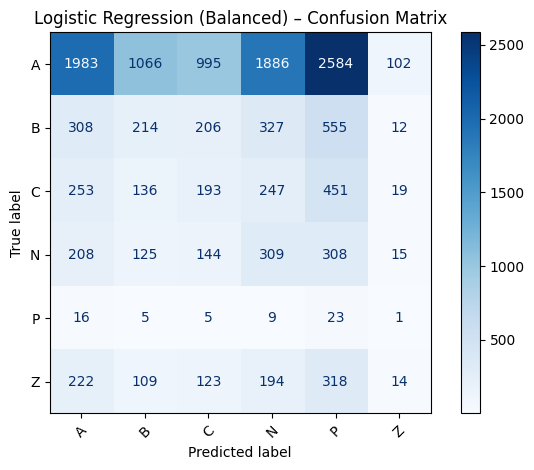

In [15]:
# Evaluate on test set
best_logreg = log_gs_balanced.best_estimator_

y_pred = best_logreg.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc:.4f}")

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=sorted(y.unique()))
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Logistic Regression (Balanced) – Confusion Matrix")
plt.tight_layout()
plt.savefig("../output/figures/logreg_balanced_confusion_matrix.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# Inspect learned coefficients
coef_matrix = best_logreg.named_steps["logreg"].coef_

print("Number of classes:", coef_matrix.shape[0])
print("Number of features:", coef_matrix.shape[1])

coefs = pd.DataFrame(
    coef_matrix,
    columns=X.columns,
    index=best_logreg.named_steps["logreg"].classes_
)

coefs

Number of classes: 6
Number of features: 5


,ZIPCODE,Latitude,Longitude,CUISINE_ENCODED,BORO_ENCODED
A,-0.098632,-1.747626,-1.666054,-0.041422,-0.047867
B,0.017834,0.826935,0.851177,0.001452,-0.054847
C,0.051965,2.429605,2.398755,0.008245,0.048022
N,-0.079182,-3.098817,-3.164488,0.065307,0.039784
P,0.134668,-0.092861,-0.147913,-0.077019,-0.009785
Z,-0.026653,1.682763,1.728523,0.043437,0.024694


The Logistic Regression model uses L2 regularization to stabilize the learned coefficients and reduce overfitting when predicting inspection grades. The modeling pipeline standardizes all numeric features within the cross-validation loop to prevent data leakage and ensure that every hyperparameter setting is evaluated under identical preprocessing conditions. GridSearchCV tests multiple values of the regularization parameter C while using class weights to address imbalance, selecting the configuration that achieves the highest cross-validated accuracy. After tuning, the final model is evaluated on the test set using accuracy, a confusion matrix, and detailed classification metrics to understand which grades are predicted correctly and where errors occur. This workflow provides a structured and reproducible approach to building and analyzing a penalized classification model.